In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

2026-03-18 14:57:59.072662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773845879.280314      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773845879.337313      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773845879.808561      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773845879.808602      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773845879.808605      55 computation_placer.cc:177] computation placer alr

In [4]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
train_dir = "/kaggle/input/datasets/chandanakuntala/cropped-lisa-traffic-light-dataset/cropped_lisa_1/train_1"
val_dir = "/kaggle/input/datasets/chandanakuntala/cropped-lisa-traffic-light-dataset/cropped_lisa_1/val_1"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=42
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Class Name found:", class_names)

train_ds = train_ds.map(lambda x, y: (x/255.0, y))
test_ds = test_ds.map(lambda x, y: (x/255.0, y))

Found 32797 files belonging to 7 classes.
Found 3737 files belonging to 7 classes.
Class Name found: ['go', 'goForward', 'goLeft', 'stop', 'stopLeft', 'warning', 'warningLeft']


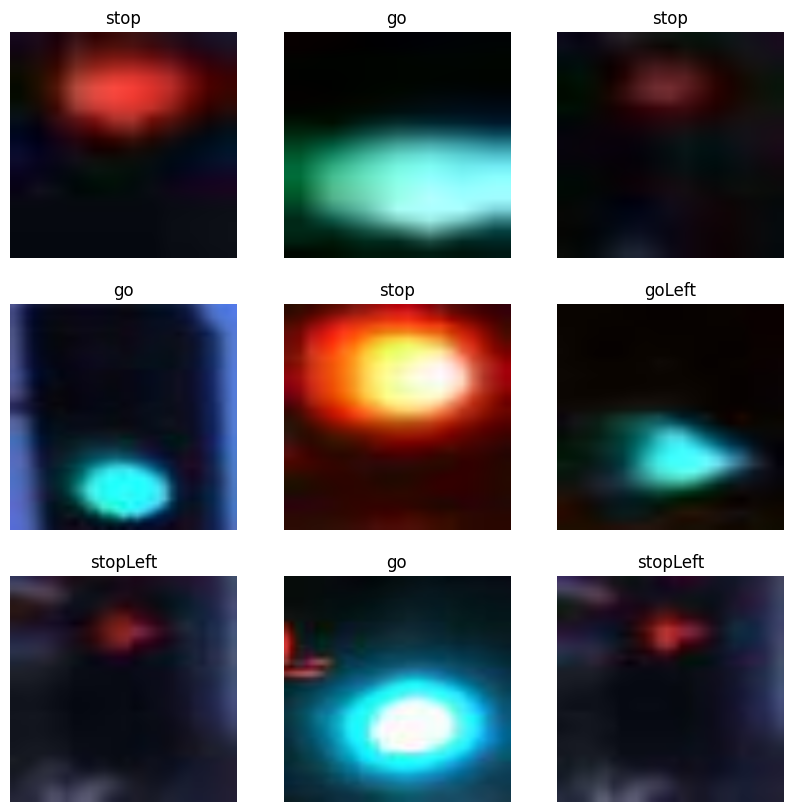

In [3]:
plt.figure(figsize=(10,10))
for image, lables in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(image[i].numpy())
    plt.title(class_names[lables[i]])
    plt.axis("off")
plt.show()

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input

model = Sequential([
    Input(shape=(256, 256, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,879 (56.61 MB)

 Trainable params: 14,839,879 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20
)

Epoch 1/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 84s 77ms/step - accuracy: 0.9092 - loss: 0.3274 - val_accuracy: 0.9224 - val_loss: 0.2985
Epoch 2/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 68s 66ms/step - accuracy: 0.9654 - loss: 0.1075 - val_accuracy: 0.9409 - val_loss: 0.1404
Epoch 3/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 68s 66ms/step - accuracy: 0.9724 - loss: 0.0807 - val_accuracy: 0.9393 - val_loss: 0.2768
Epoch 4/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 68s 66ms/step - accuracy: 0.9777 - loss: 0.0681 - val_accuracy: 0.9494 - val_loss: 0.1272
Epoch 5/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 67s 66ms/step - accuracy: 0.9826 - loss: 0.0565 - val_accuracy: 0.9516 - val_loss: 0.1315
Epoch 6/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 67s 65ms/step - accuracy: 0.9821 - loss: 0.0588 - val_accuracy: 0.9759 - val_loss: 0.0722
Epoch 7/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 67s 65ms/step - accuracy: 0.9866 - loss: 0.0418 - val_accuracy: 0.9620 - val_loss: 0.1768
Epoch 8/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 67s 65ms/step - accuracy: 0.9875 -

Grading the final exam (safely this time!)...


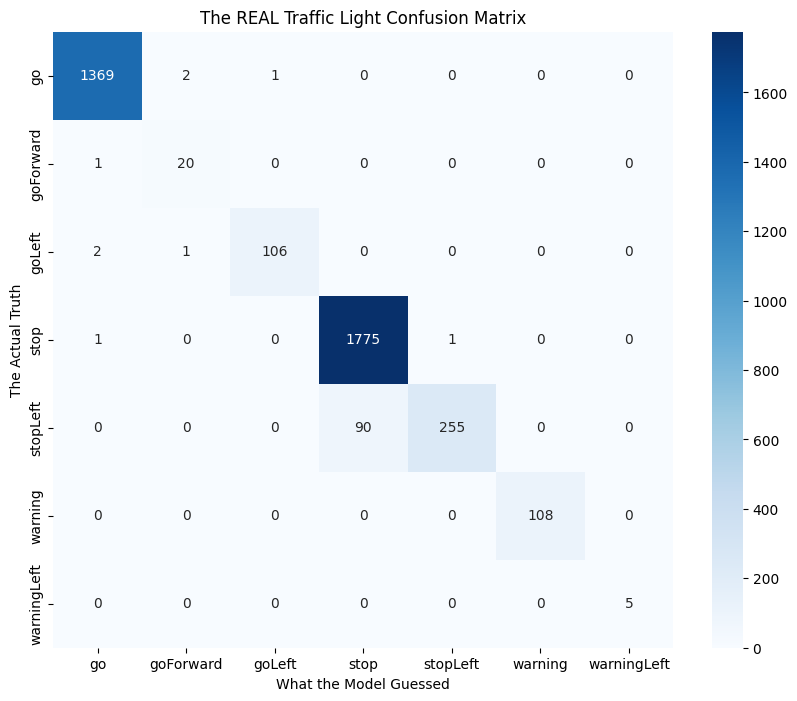

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("Grading the final exam (safely this time!)...")

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())    
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title("The REAL Traffic Light Confusion Matrix")
plt.xlabel("What the Model Guessed")
plt.ylabel("The Actual Truth")
plt.show()

In [12]:
model.save("aryean.keras")
print("Model successfully saved!")

Model successfully saved!


In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model(model)

class_names = ['go', 'goForward', 'goLeft', 'stop', 'stopLeft', 'warning', 'warningLeft']

def predict_traffic_light(image):
    img_resized = tf.image.resize_with_pad(image, target_height=256, target_width=256)
    img_normalized = img_resized / 255.0
    img_batch = tf.expand_dims(img_normalized, 0)
    
    predictions = model.predict(img_batch)
    percentages = predictions[0]
    
    return {class_names[i]: float(percentages[i]) for i in range(len(class_names))}

demo = gr.Interface(
    fn=predict_traffic_light,
    inputs=gr.Image(),
    outputs=gr.Label(num_top_classes=3),
    title="🚦 High-Def Traffic Light AI Detector",
    description="Upload a photo to see the AI's prediction."
)

demo.launch(share=True)